In [1]:
import numpy as np
import pandas as pd

In [2]:
fao = pd.read_csv('FAOSTAT_data.csv')

In [3]:
fao.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,111,Wheat,1961,1961,kg/ha,1022.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,111,Wheat,1962,1962,kg/ha,973.5,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,111,Wheat,1963,1963,kg/ha,831.7,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,111,Wheat,1964,1964,kg/ha,951.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,111,Wheat,1965,1965,kg/ha,972.3,A,Official figure,NaN


In [4]:
fao.info()

<class 'pandas.DataFrame'>
RangeIndex: 7152 entries, 0 to 7151
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       7152 non-null   str    
 1   Domain            7152 non-null   str    
 2   Area Code (M49)   7152 non-null   int64  
 3   Area              7152 non-null   str    
 4   Element Code      7152 non-null   int64  
 5   Element           7152 non-null   str    
 6   Item Code (CPC)   7152 non-null   int64  
 7   Item              7152 non-null   str    
 8   Year Code         7152 non-null   int64  
 9   Year              7152 non-null   int64  
 10  Unit              7152 non-null   str    
 11  Value             7152 non-null   float64
 12  Flag              7152 non-null   str    
 13  Flag Description  7152 non-null   str    
 14  Note              0 non-null      float64
dtypes: float64(2), int64(5), str(8)
memory usage: 838.3 KB


In [5]:
import requests

params = {
    "start": 20000101,
    "end": 20231231,
    "latitude": 30.37,      
    "longitude": 76.77,
    "community": "ag",
    "parameters": "T2M,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN",
    "format": "json",
    "units": "metric"
}

url = "https://power.larc.nasa.gov/api/temporal/daily/point"
response = requests.get(url, params=params)
data = response.json()
print(data)

{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [76.77, 30.37, 423.74]}, 'properties': {'parameter': {'T2M': {'20000101': 14.53, '20000102': 14.74, '20000103': 14.21, '20000104': 14.27, '20000105': 13.93, '20000106': 13.6, '20000107': 14.87, '20000108': 15.66, '20000109': 14.92, '20000110': 15.37, '20000111': 16.98, '20000112': 17.33, '20000113': 14.06, '20000114': 10.25, '20000115': 9.81, '20000116': 9.34, '20000117': 10.85, '20000118': 14.86, '20000119': 15.61, '20000120': 13.27, '20000121': 15.36, '20000122': 16.11, '20000123': 14.71, '20000124': 14.89, '20000125': 15.68, '20000126': 14.83, '20000127': 14.3, '20000128': 13.57, '20000129': 13.32, '20000130': 15.1, '20000131': 15.33, '20000201': 16.26, '20000202': 13.21, '20000203': 14.77, '20000204': 15.07, '20000205': 10.44, '20000206': 12.52, '20000207': 14.61, '20000208': 14.42, '20000209': 14.89, '20000210': 14.35, '20000211': 11.66, '20000212': 11.91, '20000213': 11.68, '20000214': 13.36, '20000215': 14.87, '200

In [6]:
print(fao.shape)
print(fao.head())
print(fao.columns.tolist())

(7152, 15)
  Domain Code                        Domain  Area Code (M49)         Area  \
0         QCL  Crops and livestock products                4  Afghanistan   
1         QCL  Crops and livestock products                4  Afghanistan   
2         QCL  Crops and livestock products                4  Afghanistan   
3         QCL  Crops and livestock products                4  Afghanistan   
4         QCL  Crops and livestock products                4  Afghanistan   

   Element Code Element  Item Code (CPC)   Item  Year Code  Year   Unit  \
0          5412   Yield              111  Wheat       1961  1961  kg/ha   
1          5412   Yield              111  Wheat       1962  1962  kg/ha   
2          5412   Yield              111  Wheat       1963  1963  kg/ha   
3          5412   Yield              111  Wheat       1964  1964  kg/ha   
4          5412   Yield              111  Wheat       1965  1965  kg/ha   

    Value Flag Flag Description  Note  
0  1022.0    A  Official figure   N

In [7]:
import pandas as pd

# assuming you stored the json response in `data`
properties = data['properties']['parameter']
df_nasa = pd.DataFrame(properties)
print(df_nasa.head())
print(df_nasa.shape)

            T2M  PRECTOTCORR   RH2M  ALLSKY_SFC_SW_DWN
20000101  14.53          0.0  19.35              13.76
20000102  14.74          0.0  18.58              12.53
20000103  14.21          0.0  18.56               9.12
20000104  14.27          0.0  19.36               7.79
20000105  13.93          0.0  20.29               9.22
(8766, 4)


In [8]:
print(fao['Area'].unique())
print("Total countries:", fao['Area'].nunique())

<StringArray>
[                       'Afghanistan',                            'Albania',
                            'Algeria',                             'Angola',
                          'Argentina',                            'Armenia',
                          'Australia',                            'Austria',
                         'Azerbaijan',                         'Bangladesh',
 ...
        'United Republic of Tanzania',           'United States of America',
                            'Uruguay',                               'USSR',
                         'Uzbekistan', 'Venezuela (Bolivarian Republic of)',
                              'Yemen',                       'Yugoslav SFR',
                             'Zambia',                           'Zimbabwe']
Length: 133, dtype: str
Total countries: 133


In [9]:
countries = {
    # Asia
    'India':               {'lat': 20.59, 'lon': 78.96},
    'China':               {'lat': 35.86, 'lon': 104.19},
    'Pakistan':            {'lat': 30.37, 'lon': 69.34},
    'Bangladesh':          {'lat': 23.68, 'lon': 90.35},
    'Iran (Islamic Republic of)': {'lat': 32.42, 'lon': 53.68},

    # Europe
    'France':              {'lat': 46.22, 'lon': 2.21},
    'Germany':             {'lat': 51.16, 'lon': 10.45},
    'Ukraine':             {'lat': 48.37, 'lon': 31.16},
    'Poland':              {'lat': 51.91, 'lon': 19.14},

    # Americas
    'United States of America': {'lat': 37.09, 'lon': -95.71},
    'Brazil':              {'lat': -14.23, 'lon': -51.92},
    'Argentina':           {'lat': -38.41, 'lon': -63.61},
    'Mexico':              {'lat': 23.63, 'lon': -102.55},
    'Canada':              {'lat': 56.13, 'lon': -106.34},
    
    # Africa
    'Ethiopia':            {'lat': 9.14,  'lon': 40.48},
    'Nigeria':             {'lat': 9.08,  'lon': 8.67},
    'Egypt':               {'lat': 26.82, 'lon': 30.80},
    'South Africa':        {'lat': -30.55,'lon': 22.93},

    # Oceania
    'Australia':           {'lat': -25.27,'lon': 133.77},
}

In [10]:
import requests
import pandas as pd
import time

def get_nasa_yearly(country_name, lat, lon, start=20000101, end=20231231):
    params = {
        "start": start,
        "end": end,
        "latitude": lat,
        "longitude": lon,
        "community": "ag",
        "parameters": "T2M,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN",
        "format": "json",
        "units": "metric"
    }
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    response = requests.get(url, params=params)
    data = response.json()

    props = data['properties']['parameter']
    df = pd.DataFrame(props).reset_index()
    df.columns = ['date', 'T2M', 'PRECTOTCORR', 'RH2M', 'ALLSKY_SFC_SW_DWN']
    df['year'] = df['date'].astype(str).str[:4].astype(int)
    df['country'] = country_name

    yearly = df.groupby(['country', 'year']).agg(
        avg_temp=('T2M', 'mean'),
        total_rainfall=('PRECTOTCORR', 'sum'),
        avg_humidity=('RH2M', 'mean'),
        avg_solar=('ALLSKY_SFC_SW_DWN', 'mean')
    ).reset_index()

    return yearly

In [11]:
# Step 2: loop through all countries
all_nasa = []

for country, coords in countries.items():
    print(f"Fetching {country}...")
    try:
        df = get_nasa_yearly(country, coords['lat'], coords['lon'])
        all_nasa.append(df)
        time.sleep(2)  # be polite to the API, avoid rate limiting
    except Exception as e:
        print(f"  Failed for {country}: {e}")

nasa_all_countries = pd.concat(all_nasa, ignore_index=True)
print("Done! Shape:", nasa_all_countries.shape)
print(nasa_all_countries.head())

Fetching India...
Fetching China...
Fetching Pakistan...
Fetching Bangladesh...
Fetching Iran (Islamic Republic of)...
Fetching France...
Fetching Germany...
Fetching Ukraine...
Fetching Poland...
Fetching United States of America...
Fetching Brazil...
Fetching Argentina...
Fetching Mexico...
Fetching Canada...
Fetching Ethiopia...
Fetching Nigeria...
Fetching Egypt...
Fetching South Africa...
Fetching Australia...
Done! Shape: (456, 6)
  country  year   avg_temp  total_rainfall  avg_humidity  avg_solar
0   India  2000  27.078934          766.66     47.272486  20.068962
1   India  2001  26.996329          974.62     53.767260  18.953123
2   India  2002  27.681616          909.58     49.559863  19.371068
3   India  2003  27.190904         1118.08     56.369890  19.126329
4   India  2004  27.241940          724.99     53.307377  19.792596


In [12]:
# Step 3: clean FAO and filter to same countries
fao_clean = fao[['Area', 'Year', 'Value']].copy()
fao_clean.columns = ['country', 'year', 'yield_tons_ha']
fao_clean['yield_tons_ha'] = fao_clean['yield_tons_ha'] / 1000
fao_clean.dropna(subset=['yield_tons_ha'], inplace=True)

# keep only countries we have NASA data for
fao_filtered = fao_clean[fao_clean['country'].isin(countries.keys())]

# Step 4: merge
merged = pd.merge(fao_filtered, nasa_all_countries, on=['country', 'year'], how='inner')
print("Final merged shape:", merged.shape)

Final merged shape: (456, 7)


In [16]:
print(merged.sample(10))

       country  year  yield_tons_ha   avg_temp  total_rainfall  avg_humidity  \
430    Ukraine  2022         3.9249   9.638986          517.71     74.295425   
156      Egypt  2012         6.5823  21.717049            1.84     36.462350   
146      Egypt  2002         6.4345  21.970219            1.25     37.009452   
192     France  2000         7.1175   9.675492          852.95     82.606913   
350   Pakistan  2014         2.8241  19.398274           72.47     29.798795   
108     Canada  2012         2.8743  -1.474809          740.31     87.840874   
189   Ethiopia  2021         2.9223  21.205699         1163.28     58.730767   
19   Argentina  2019         2.9387  16.047315          398.77     52.367890   
158      Egypt  2014         6.1752  22.172055            1.17     37.138219   
251      India  2011         2.9886  26.724986          905.56     56.616712   

     avg_solar  
430  12.360027  
156  22.848579  
146  23.226219  
192  12.385000  
350  20.229041  
108  10.818907  


In [17]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [18]:
# check missing values 
print("Missing values:\n", merged.isnull().sum())

Missing values:
 country           0
year              0
yield_tons_ha     0
avg_temp          0
total_rainfall    0
avg_humidity      0
avg_solar         0
dtype: int64


In [24]:
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler

le = LabelEncoder()
merged['country_encoded'] = le.fit_transform(merged['country'])

features = ['avg_temp', 'total_rainfall', 'avg_humidity', 
            'avg_solar', 'country_encoded']

X = merged[features]
y = merged['yield_tons_ha']

print("X shape:", X.shape)
print(X.head())
print("\nData types:\n", X.dtypes)  

X shape: (456, 5)
    avg_temp  total_rainfall  avg_humidity  avg_solar  country_encoded
0  15.151202          575.42     60.461230  17.690601                0
1  15.742493          765.38     63.607123  16.864164                0
2  15.475342          648.46     57.972603  16.750959                0
3  16.281425          478.46     52.054438  17.647233                0
4  15.792568          779.73     62.194536  16.908333                0

Data types:
 avg_temp           float64
total_rainfall     float64
avg_humidity       float64
avg_solar          float64
country_encoded      int64
dtype: object


In [25]:
# Step 3: create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# see what new features were created
feature_names = poly.get_feature_names_out(features)
print("Original features:", len(features))
print("After polynomial:", len(feature_names))
print("\nNew feature names:", feature_names)

Original features: 5
After polynomial: 20

New feature names: ['avg_temp' 'total_rainfall' 'avg_humidity' 'avg_solar' 'country_encoded'
 'avg_temp^2' 'avg_temp total_rainfall' 'avg_temp avg_humidity'
 'avg_temp avg_solar' 'avg_temp country_encoded' 'total_rainfall^2'
 'total_rainfall avg_humidity' 'total_rainfall avg_solar'
 'total_rainfall country_encoded' 'avg_humidity^2'
 'avg_humidity avg_solar' 'avg_humidity country_encoded' 'avg_solar^2'
 'avg_solar country_encoded' 'country_encoded^2']


In [26]:
# Step 4: scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42 
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 364
Testing samples:  92


In [28]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [29]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.3f} tons/ha")
print(f"R²   : {r2:.3f}")

RMSE : 0.927 tons/ha
R²   : 0.695


In [30]:
# Step 5: see actual vs predicted side by side
results = pd.DataFrame({
    'country':    merged.loc[y_test.index, 'country'].values,
    'year':       merged.loc[y_test.index, 'year'].values,
    'actual':     y_test.values,
    'predicted':  y_pred.round(3)
})
print(results.head(10))

        country  year  actual  predicted
0        Poland  2013  4.4367      4.912
1     Australia  2015  1.9743      2.682
2      Pakistan  2004  2.3733      1.506
3       Germany  2002  6.9056      7.296
4         Egypt  2011  6.5428      5.438
5        France  2007  6.2542      6.826
6      Ethiopia  2004  1.4691      4.050
7        Canada  2005  2.7381      3.660
8  South Africa  2018  3.7111      3.027
9     Australia  2006  0.9173      2.557


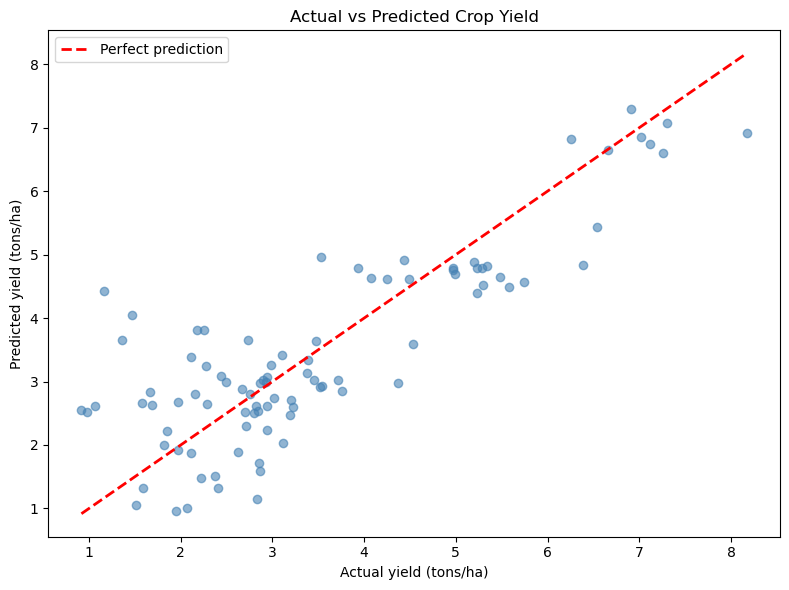

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual yield (tons/ha)')
plt.ylabel('Predicted yield (tons/ha)')
plt.title('Actual vs Predicted Crop Yield')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# tune Ridge alpha - find the best value
from sklearn.linear_model import RidgeCV

# RidgeCV automatically finds the best alpha
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0], cv=5)
ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.alpha_)

y_pred_cv = ridge_cv.predict(X_test)
rmse_cv = np.sqrt(mean_squared_error(y_test, y_pred_cv))
r2_cv   = r2_score(y_test
                   , y_pred_cv)

print(f"RMSE : {rmse_cv:.3f} tons/ha")
print(f"R²   : {r2_cv:.3f}")

Best alpha: 0.01
RMSE : 0.837 tons/ha
R²   : 0.751


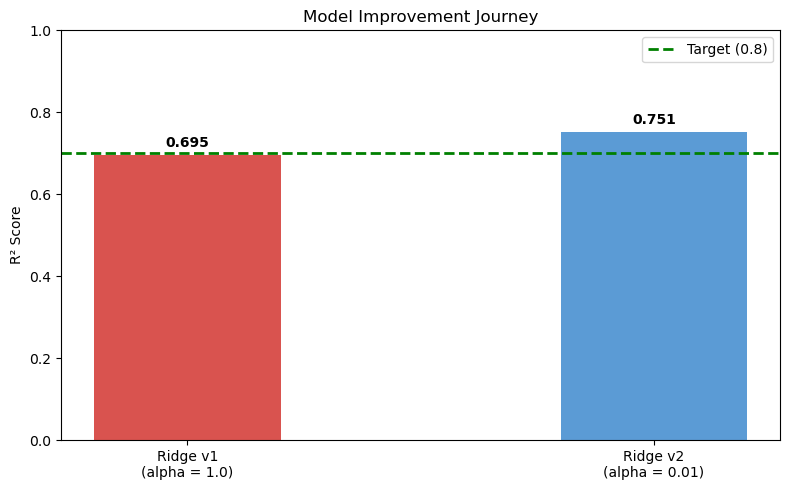

In [42]:
# visualize the improvement journey
models_scores = {
    'Ridge v1\n(alpha = 1.0)': 0.695,
    'Ridge v2\n(alpha = 0.01)': 0.751,
}

plt.figure(figsize=(8, 5))
bars = plt.bar(models_scores.keys(), models_scores.values(), 
               color=['#d9534f', '#5b9bd5'], width=0.4)
plt.axhline(y=0.7, color='green', linestyle='--', linewidth=2, label='Target (0.8)')
plt.ylabel('R² Score')
plt.title('Model Improvement Journey')
plt.ylim(0, 1.0)
plt.legend()
for bar, val in zip(bars, models_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.02, 
             f'{val}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# also check Random Forest score now with the improved features
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"\nRandom Forest:")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"R²   : {(r2_rf):.3f}")


Random Forest:
RMSE : 0.499
R²   : 0.912


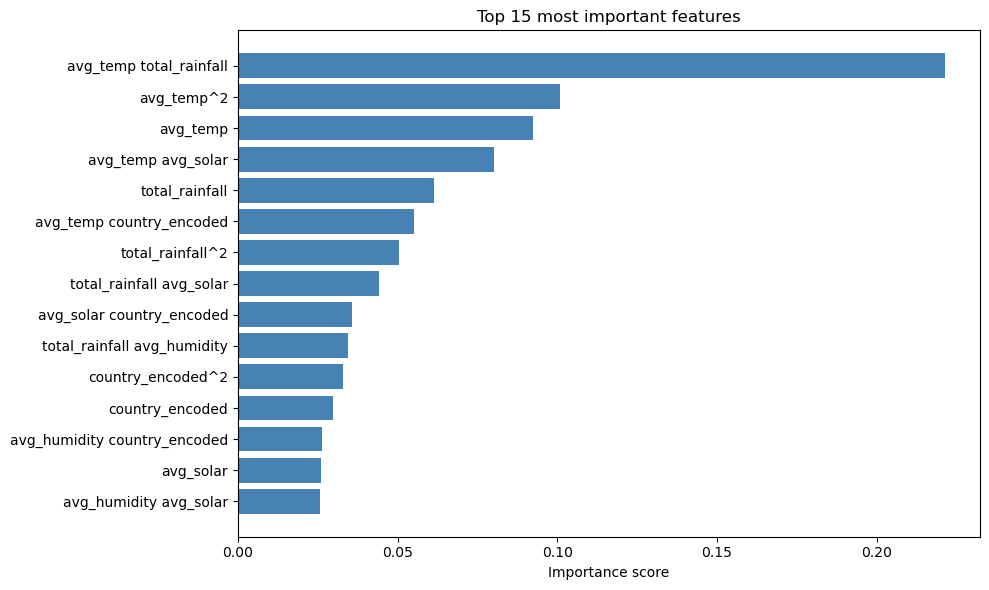

In [45]:
# get feature importances from random forest
feature_names_v2 = poly.get_feature_names_out(features)
importances = rf.feature_importances_

# sort by importance
indices = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names_v2[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color='steelblue'
)
plt.xlabel('Importance score')
plt.title('Top 15 most important features')
plt.tight_layout()
plt.show()

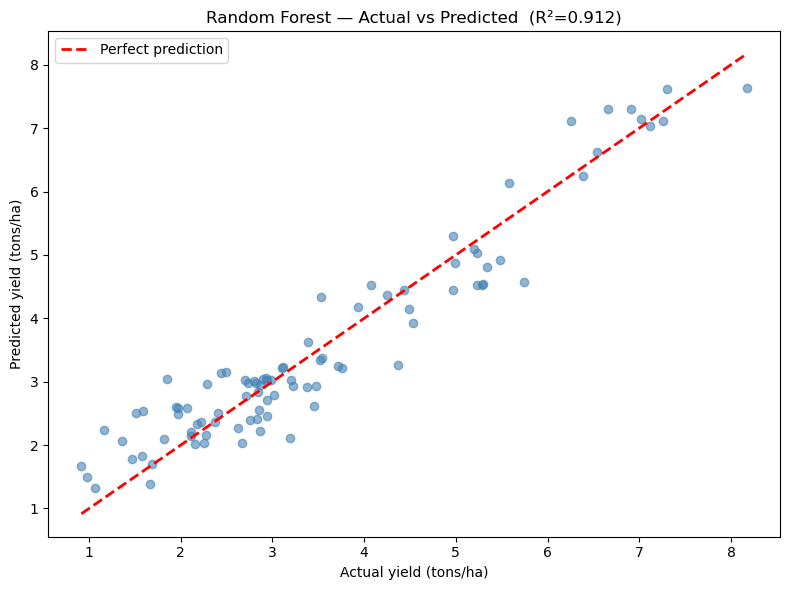

In [53]:
# also final actual vs predicted plot

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual yield (tons/ha)')
plt.ylabel('Predicted yield (tons/ha)')
plt.title(f'Random Forest — Actual vs Predicted  (R²={r2_rf:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# save final model 
import joblib

joblib.dump(rf, 'crop_yield_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(poly, 'poly.pkl')

print("Model saved successfully!")

Model saved successfully!


In [56]:
merged.to_csv('merged.csv', index=False)